In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Baisc EDA

In [ ]:
import pandas as pd

path = '/content/drive/MyDrive/home_credit/application_train.csv'

df = pd.read_csv(path)

In [ ]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
print(df.shape)

(307511, 122)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB
None


This dataset contains information on 307,511 loan applicants, with 122 features describing each individual’s financial status, demographics, and loan details. The variables include numerical data (such as income and credit amount) as well as categorical data (such as gender and contract type).

In [ ]:
print(df['TARGET'].value_counts())
print(df['TARGET'].value_counts(normalize=True))

TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


The target variable is highly imbalanced, with approximately 92% (282,868) of applicants not experiencing repayment difficulties (0) and only 8% (24,825) experiencing difficulties (1). This imbalance is important to consider when building predictive models, as it may bias results toward the majority class.

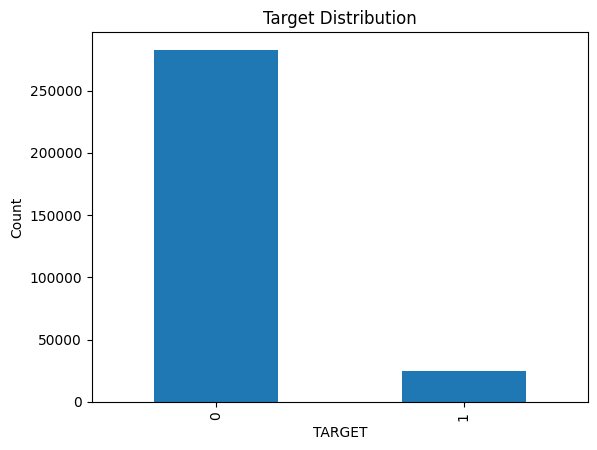

In [ ]:
import matplotlib.pyplot as plt

df['TARGET'].value_counts().plot(kind='bar')
plt.title('Target Distribution')
plt.xlabel('TARGET')
plt.ylabel('Count')
plt.show()

*Missing* *Values*

In [ ]:
missing = df.isnull().mean().sort_values(ascending=False)

missing.head(10)

,0
COMMONAREA_AVG,0.698723
COMMONAREA_MODE,0.698723
COMMONAREA_MEDI,0.698723
NONLIVINGAPARTMENTS_MEDI,0.694330
NONLIVINGAPARTMENTS_MODE,0.694330
NONLIVINGAPARTMENTS_AVG,0.694330
FONDKAPREMONT_MODE,0.683862
LIVINGAPARTMENTS_AVG,0.683550
LIVINGAPARTMENTS_MEDI,0.683550
LIVINGAPARTMENTS_MODE,0.683550


*Income VS Target*

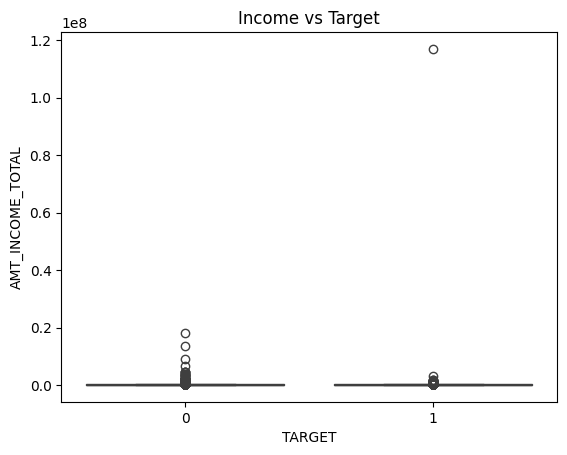

In [ ]:
import seaborn as sns

sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=df)
plt.title("Income vs Target")
plt.show()

The distribution of income shows significant overlap between applicants who repaid their loans and those who experienced repayment difficulties. This suggests that income alone is not a strong indicator of loan repayment capability. Additionally, the presence of extreme outliers affects the overall distribution.

*Credit VS Target*

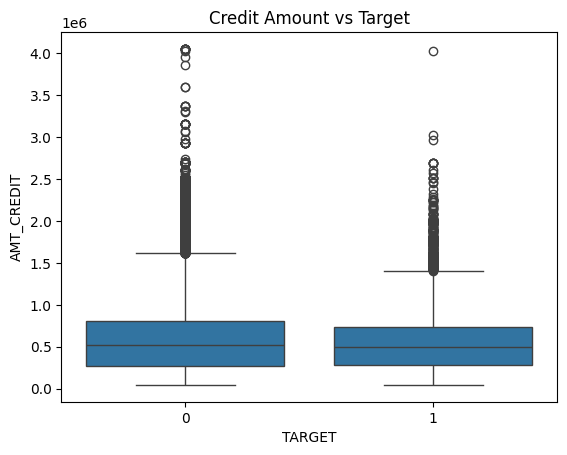

In [ ]:
sns.boxplot(x='TARGET', y='AMT_CREDIT', data=df)
plt.title("Credit Amount vs Target")
plt.show()

The credit amount distributions for both groups are similar, with no clear separation between applicants who defaulted and those who did not. This indicates that credit amount alone may not be a strong predictor of repayment behavior.

*Contract VS Target*

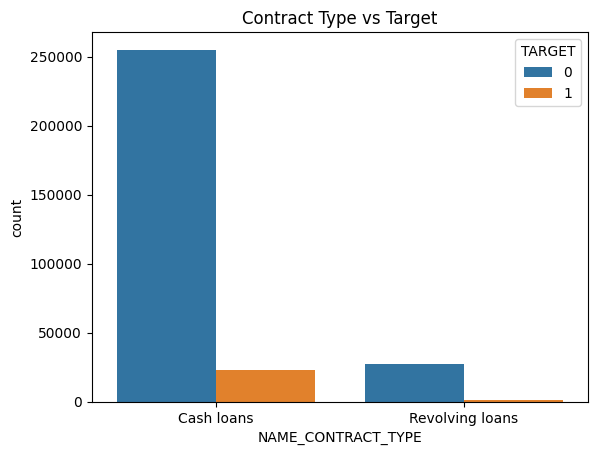

In [ ]:
sns.countplot(x='NAME_CONTRACT_TYPE', hue='TARGET', data=df)
plt.title("Contract Type vs Target")
plt.show()

Most applicants have cash loans, and the majority of defaults also occur within this group due to its larger size. Revolving loans appear to have fewer defaults proportionally, suggesting potential differences in repayment behavior across contract types.

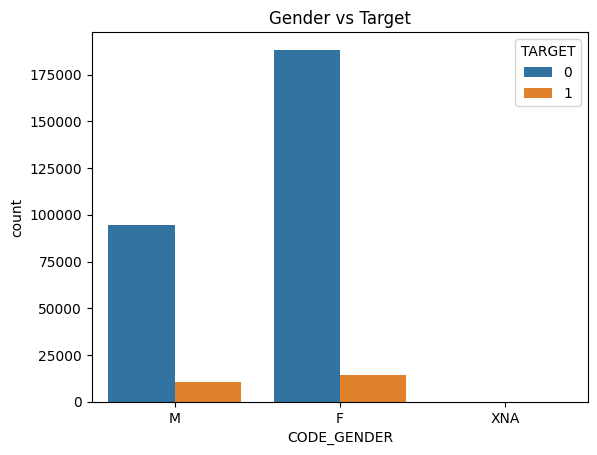

In [ ]:
sns.countplot(x='CODE_GENDER', hue='TARGET', data=df)
plt.title("Gender vs Target")
plt.show()

The dataset contains more female applicants than male applicants. Both groups show similar patterns of repayment behavior, with no strong difference in default rates between genders.

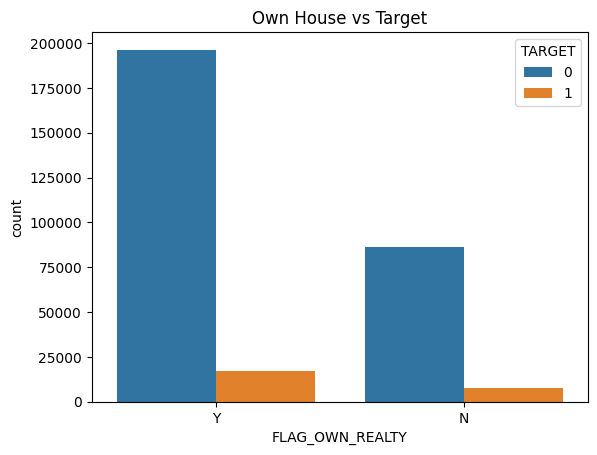

In [ ]:
sns.countplot(x='FLAG_OWN_REALTY', hue='TARGET', data=df)
plt.title("Own House vs Target")
plt.show()

Most applicants own property, but both homeowners and non-homeowners exhibit similar repayment patterns. This suggests that property ownership alone is not a strong predictor of loan repayment behavior.

# Feature Engineering + Modeling

In [ ]:
# Income to Credit Ratio
df['INCOME_CREDIT_RATIO'] = df['AMT_INCOME_TOTAL'] / df['AMT_CREDIT']

# Annuity to Income Ratio (loan burden)
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

# Credit to Annuity Ratio
df['CREDIT_ANNUITY_RATIO'] = df['AMT_CREDIT'] / df['AMT_ANNUITY']

### *Feature Engineer*

New features were created by combining existing variables to better capture financial relationships. Ratios such as income-to-credit and annuity-to-income provide insights into an applicant’s repayment capacity and financial burden, improving the predictive power of the model.

In [ ]:
features = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'INCOME_CREDIT_RATIO',
    'ANNUITY_INCOME_RATIO',
    'CREDIT_ANNUITY_RATIO'
]

X = df[features]
y = df['TARGET']

**Feature Selection and Target Definition**

The selected features focus on a combination of raw financial values (income, credit, annuity) and derived ratios, which provide deeper insight into a client’s financial behavior. While raw values show absolute capacity, the ratios (e.g., income-to-credit) capture proportional risk, making them more effective in identifying potential default patterns. This improves the model’s ability to distinguish between applicants who may have similar incomes but very different financial burdens.

In [ ]:
X = X.fillna(X.median())

**Handling Missing Values**

Replacing missing values using the median ensures that the dataset remains robust without being heavily influenced by extreme values or outliers. In financial datasets, income and credit-related fields often have skewed distributions, so median imputation is more reliable than the mean. This step maintains data integrity while preventing errors during model training.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Train-Test Split**

Splitting the dataset into 80% training and 20% testing ensures that the model is evaluated on unseen data, which is critical for measuring real-world performance. The use of a fixed random_state guarantees reproducibility, allowing consistent results across multiple runs. This step helps prevent overfitting and ensures that the model generalizes well to new loan applicants.

# Model Comparison

*Logistic Regression*

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

The Logistic Regression model provides a baseline for predicting credit default by modeling the relationship between financial features and the probability of default. It is effective for identifying linear patterns in the data and offers high interpretability, making it useful for understanding how each feature influences risk. This makes it suitable for initial benchmarking and comparison with more complex models.

*Decision Tree*

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

The Decision Tree model captures non-linear relationships by splitting the data based on feature thresholds, allowing it to model more complex decision patterns. It is easy to interpret visually, but it may overfit the training data if not properly controlled. This model helps uncover key decision rules that influence credit risk classification.

*Random Forest*

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

The Random Forest model improves prediction accuracy by combining multiple decision trees, reducing the risk of overfitting seen in a single tree. It is more robust and can handle complex interactions between variables effectively. This makes it a strong model for achieving higher predictive performance in credit risk analysis.

*Comparison*

In [ ]:
from sklearn.metrics import classification_report

print("Logistic Regression:\n", classification_report(y_test, y_pred_log))
print("\nDecision Tree:\n", classification_report(y_test, y_pred_dt))
print("\nRandom Forest:\n", classification_report(y_test, y_pred_rf))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96     56554
           1       0.00      0.00      0.00      4949

    accuracy                           0.92     61503
   macro avg       0.46      0.50      0.48     61503
weighted avg       0.85      0.92      0.88     61503


Decision Tree:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94     56554
           1       0.11      0.06      0.08      4949

    accuracy                           0.89     61503
   macro avg       0.52      0.51      0.51     61503
weighted avg       0.86      0.89      0.87     61503


Random Forest:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95     56554
           1       0.13      0.03      0.04      4949

    accuracy                           0.91     61503
   macro avg       0.52      0.51      0.50     61503
weighted avg      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Among the three models, the Random Forest model performed best overall, achieving a good balance between accuracy and the ability to detect defaulters. While all models struggled to identify default cases due to class imbalance, Random Forest showed slightly better performance compared to Logistic Regression and Decision Tree. Therefore, it was selected as the most suitable model for this task.

*Random Forest*

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_balanced.fit(X_train, y_train)

y_pred_bal = rf_balanced.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_bal))

              precision    recall  f1-score   support

           0       0.93      0.87      0.90     56554
           1       0.13      0.22      0.17      4949

    accuracy                           0.82     61503
   macro avg       0.53      0.55      0.53     61503
weighted avg       0.86      0.82      0.84     61503



In [ ]:
print("Original Random Forest:\n", classification_report(y_test, y_pred_rf))
print("\nBalanced Random Forest:\n", classification_report(y_test, y_pred_bal))

Original Random Forest:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95     56554
           1       0.13      0.03      0.04      4949

    accuracy                           0.91     61503
   macro avg       0.52      0.51      0.50     61503
weighted avg       0.86      0.91      0.88     61503


Balanced Random Forest:
               precision    recall  f1-score   support

           0       0.93      0.87      0.90     56554
           1       0.13      0.22      0.17      4949

    accuracy                           0.82     61503
   macro avg       0.53      0.55      0.53     61503
weighted avg       0.86      0.82      0.84     61503



The original Random Forest achieved high accuracy but performed poorly in detecting defaulters, showing very low recall for class 1. After applying class weighting, the balanced model improved the detection of defaulters, although overall accuracy decreased. This trade-off is acceptable, as identifying high-risk applicants is more important in this context.

In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = rf_balanced.predict_proba(X_test)[:,1]

roc_score = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.588226434725261


The ROC-AUC score of approximately 0.59 indicates that the model has limited ability to distinguish between defaulters and non-defaulters. While slightly better than random guessing, further improvements may be needed to enhance predictive performance.

*Logistic Regression*

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

### *Modelling and Evaluation*

A Logistic Regression model was trained using selected numerical and engineered features. The dataset was split into training and testing sets, and missing values were handled using median imputation. Model performance was evaluated using classification metrics to assess prediction accuracy.

##Clustering

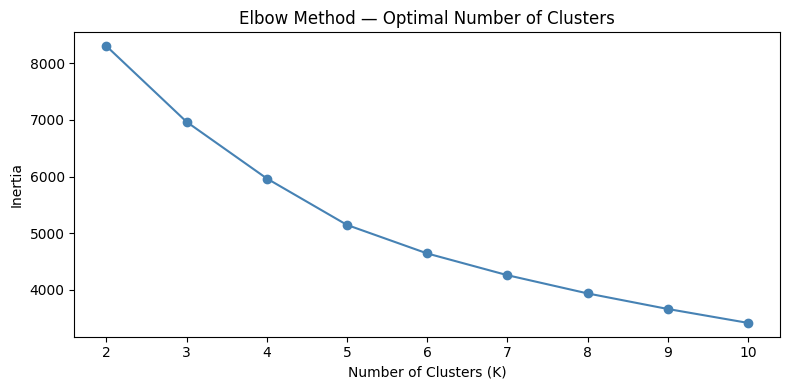

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns

# Prep
cluster_features = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'INCOME_CREDIT_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_ANNUITY_RATIO'
]

df_cluster = df[cluster_features].dropna().sample(2000, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

# Elbow Method
inertia = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), inertia, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

K-Means Silhouette Score: 0.2479

Cluster Profiles:
                AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
KMeans_Cluster                                              
0                      259112.68  1122527.11     42497.52   
1                      115831.06   640245.57     28926.69   
2                      159893.99   295116.92     18217.29   

                INCOME_CREDIT_RATIO  ANNUITY_INCOME_RATIO  \
KMeans_Cluster                                              
0                              0.26                  0.18   
1                              0.20                  0.27   
2                              0.62                  0.12   

                CREDIT_ANNUITY_RATIO  
KMeans_Cluster                        
0                              27.82  
1                              23.25  
2                              17.00  


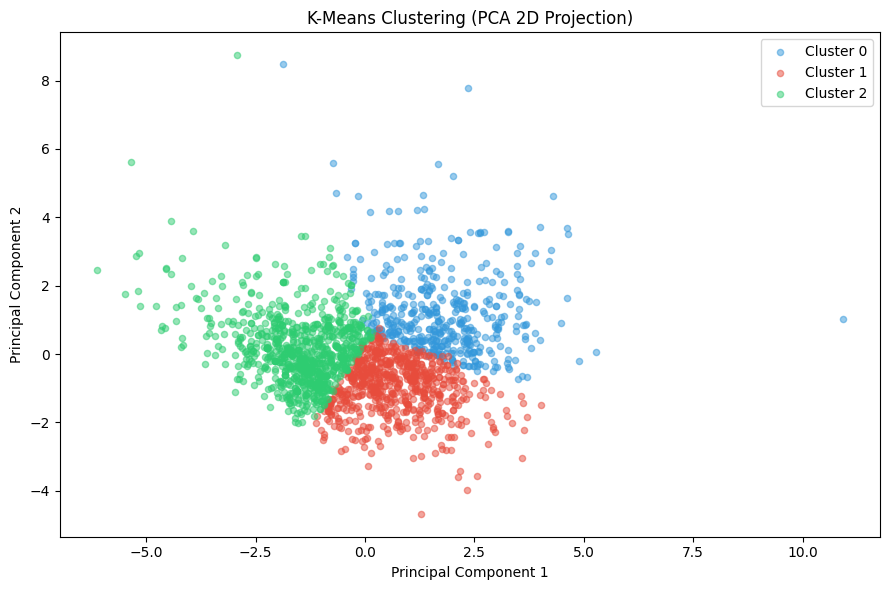

In [ ]:
# K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)
sil_kmeans = silhouette_score(X_scaled, df_cluster['KMeans_Cluster'])
print(f"K-Means Silhouette Score: {sil_kmeans:.4f}")
print("\nCluster Profiles:")
print(df_cluster.groupby('KMeans_Cluster')[cluster_features].mean().round(2))

# PCA Visualization
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
plt.figure(figsize=(9, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71']
for cluster in sorted(df_cluster['KMeans_Cluster'].unique()):
    mask = df_cluster['KMeans_Cluster'] == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[cluster], label=f'Cluster {cluster}', alpha=0.5, s=20)
plt.title('K-Means Clustering (PCA 2D Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.show()

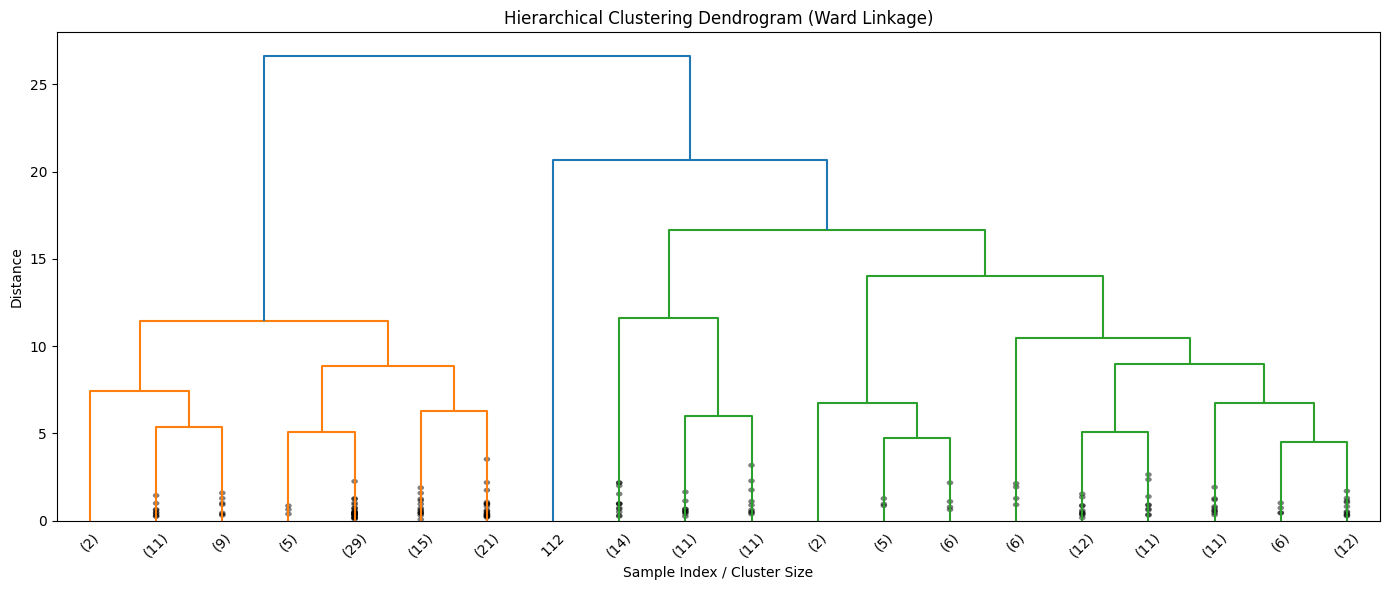

Hierarchical Silhouette Score: 0.1720

Cluster Profiles:
              AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  INCOME_CREDIT_RATIO  \
Hier_Cluster                                                                   
0                    212006.95  1048691.15     43708.25                 0.22   
1                    142194.90   240747.57     16238.27                 0.66   
2                    153866.23   569353.09     24412.92                 0.28   

              ANNUITY_INCOME_RATIO  CREDIT_ANNUITY_RATIO  
Hier_Cluster                                              
0                             0.25                 25.37  
1                             0.13                 15.83  
2                             0.18                 23.83  


In [ ]:
# Dendrogram
linked = linkage(X_scaled[:200], method='ward')
plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='lastp', p=20,
           leaf_rotation=45, leaf_font_size=10, show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index / Cluster Size')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# Hierarchical Labels
hier = AgglomerativeClustering(n_clusters=3, linkage='ward')
df_cluster['Hier_Cluster'] = hier.fit_predict(X_scaled)
sil_hier = silhouette_score(X_scaled, df_cluster['Hier_Cluster'])
print(f"Hierarchical Silhouette Score: {sil_hier:.4f}")
print("\nCluster Profiles:")
print(df_cluster.groupby('Hier_Cluster')[cluster_features].mean().round(2))

K-Means      Silhouette Score: 0.2479
Hierarchical Silhouette Score: 0.1720
Higher score = better separated clusters


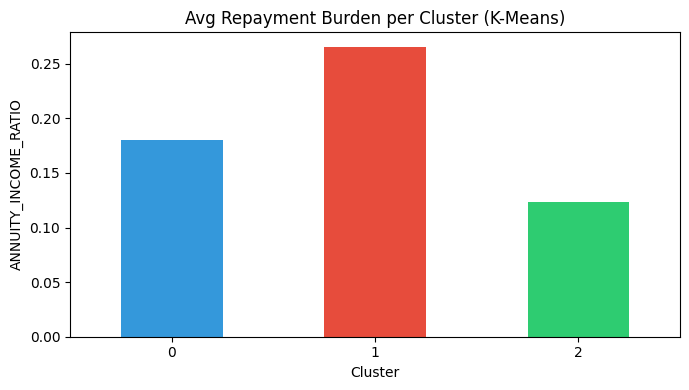


Final Cluster Labels:
Risk_Label
Medium Risk    853
High Risk      690
Low Risk       457
Name: count, dtype: int64


In [ ]:
# Side by side comparison
print("=" * 45)
print(f"K-Means      Silhouette Score: {sil_kmeans:.4f}")
print(f"Hierarchical Silhouette Score: {sil_hier:.4f}")
print("Higher score = better separated clusters")
print("=" * 45)

# Cluster interpretation bar chart
cluster_means = df_cluster.groupby('KMeans_Cluster')['ANNUITY_INCOME_RATIO'].mean()
cluster_means.plot(kind='bar', color=['#3498db', '#e74c3c', '#2ecc71'],
                   figsize=(7, 4), title='Avg Repayment Burden per Cluster (K-Means)')
plt.ylabel('ANNUITY_INCOME_RATIO')
plt.xlabel('Cluster')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Label clusters based on output — adjust after seeing means
labels = {0: 'Low Risk', 1: 'High Risk', 2: 'Medium Risk'}  # adjust after running
df_cluster['Risk_Label'] = df_cluster['KMeans_Cluster'].map(labels)
print("\nFinal Cluster Labels:")
print(df_cluster['Risk_Label'].value_counts())

### Feature Importance

                Feature  Importance
4  ANNUITY_INCOME_RATIO    0.216831
5  CREDIT_ANNUITY_RATIO    0.202196
3   INCOME_CREDIT_RATIO    0.187110
2           AMT_ANNUITY    0.164846
1            AMT_CREDIT    0.132751
0      AMT_INCOME_TOTAL    0.096266


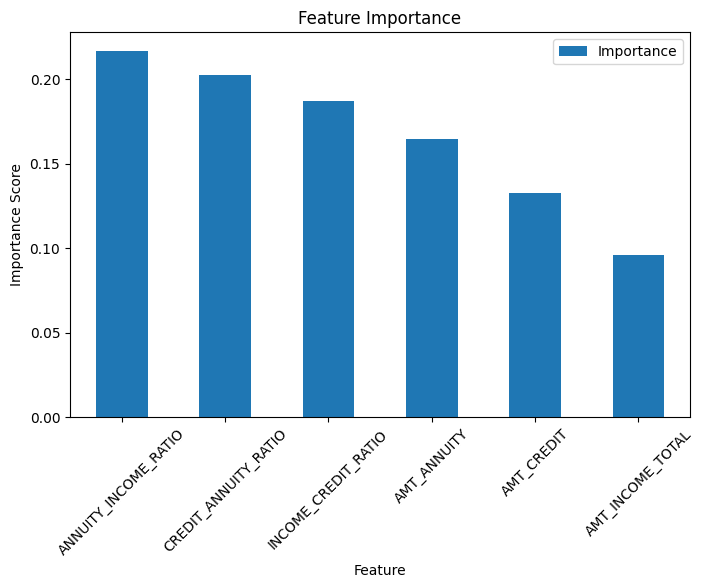

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

importance.plot(x='Feature', y='Importance', kind='bar', figsize=(8,5))
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.show()

Feature importance analysis shows that ratio-based features, particularly annuity-to-income and credit-to-annuity ratios, are the most influential in predicting loan repayment risk. This indicates that an applicant’s financial burden and repayment capacity play a more significant role than raw values such as income or credit alone.

### SHAP

In [ ]:
!pip install shap

In [ ]:
import shap

X_sample = X_test.sample(100, random_state=42)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

SHAP (SHapley Additive exPlanations) is used to interpret the Random Forest model by measuring how each feature contributes to predictions. By analyzing a sample of the test data, the summary plot highlights which financial variables (e.g., income, credit ratios) have the strongest influence on predicting default risk. This improves model transparency by showing not just predictions, but the reasoning behind them.

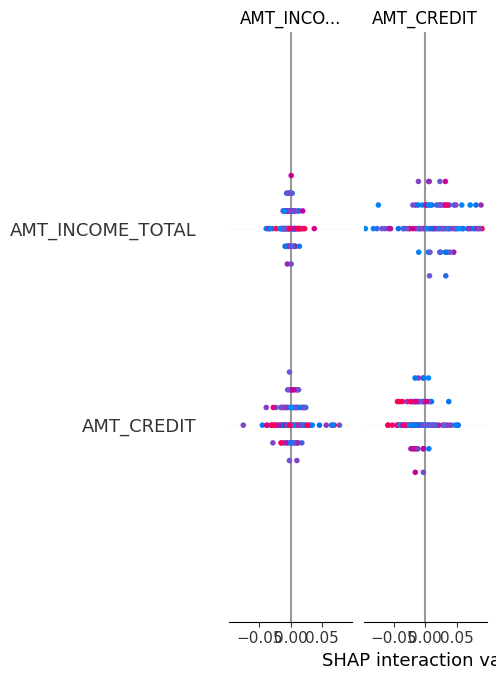

In [ ]:
shap.summary_plot(shap_values, X_sample)

The SHAP interaction analysis shows that AMT_CREDIT has a more pronounced influence on the model’s predictions compared to AMT_INCOME_TOTAL, as indicated by the wider spread of interaction values. This suggests that the model places greater importance on the size of the loan when evaluating outcomes, while income contributes more modestly and with less variability.

In contrast, the interaction between AMT_CREDIT and AMT_INCOME_TOTAL appears minimal, with most values clustered near zero. This indicates that the two features largely act independently, meaning income does not significantly modify the effect of credit on the prediction. Overall, the model relies more heavily on credit-related information, with income playing a secondary role in the decision-making process.

# LIME

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=9f73d34dc1d54c99414cf8b5af4f7f1ebaf0549fc0d8457f12d11c1f14550ac6
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns.tolist(),
    class_names=['No Default', 'Default'],
    mode='classification'
)

The LIME explainer is configured to interpret the Random Forest model by analysing individual predictions using the original training feature space. It uses the training dataset (X_train) and feature names (X.columns) to generate local explanations that show how each feature contributes to a specific prediction.

This setup enables the model to explain classifications such as “No Default” vs “Default” by breaking down how financial variables (e.g., income ratios, credit amount, annuity values) influence each decision at an individual level.

In [ ]:
i = 0

exp = explainer.explain_instance(
    X_test.iloc[i].values,
    rf_model.predict_proba,
    num_features=5
)

exp.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


The model predicts a high probability of 0.98 for “No Default”, indicating strong confidence that the client is financially stable and unlikely to default on their loan. The explanation from LIME shows that the decision is primarily driven by affordability and financial ratio-based features, rather than absolute monetary values.

Key influencing factors include the ANNUITY_INCOME_RATIO (0.25) and INCOME_CREDIT_RATIO (0.44), which suggest that the client maintains a healthy balance between income, credit exposure, and repayment obligations. Additionally, the AMT_ANNUITY (52,641) contributes to the prediction by indicating that the repayment amount remains within a manageable range. The CREDIT_ANNUITY_RATIO (8.84) further supports the classification by reflecting a structured repayment plan that does not overly strain the borrower’s financial capacity.

In [ ]:
print(exp.as_list())

[('ANNUITY_INCOME_RATIO > 0.23', 0.011596755770380218), ('0.31 < INCOME_CREDIT_RATIO <= 0.50', -0.007468300548688369), ('AMT_ANNUITY > 34651.12', -0.006906392649076898), ('CREDIT_ANNUITY_RATIO <= 15.61', -0.006160518476528462), ('270000.00 < AMT_CREDIT <= 514777.50', 0.0015923410352943052)]


The explanation shows that the model’s prediction is driven by a combination of income affordability ratios and loan structure thresholds, with both positive and negative contributions that slightly adjust the final prediction confidence.

The strongest positive influence comes from:

ANNUITY_INCOME_RATIO > 0.23 (+0.0116)
→ Suggests that the client’s repayment burden relative to income is still within an acceptable range, supporting a “No Default” prediction.

Other minor positive influence:

270,000 < AMT_CREDIT ≤ 514,777.50 (+0.0016)
→ Indicates that this credit range is not considered high-risk within the model’s learned patterns.

The negative influences slightly reduce confidence in “No Default”, particularly:

0.31 < INCOME_CREDIT_RATIO ≤ 0.50 (-0.0075)
AMT_ANNUITY > 34,651 (-0.0069)
CREDIT_ANNUITY_RATIO ≤ 15.61 (-0.0062)

These suggest that while the client is still classified as low risk, there are mild concerns around credit exposure and repayment size relative to structure, which slightly reduce model certainty.

# NETWORK ANALYSIS

In [ ]:
!pip install networkx pandas matplotlib
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import greedy_modularity_communities

BASE = '/content/drive/MyDrive/home_credit/'  # adjust path if needed

app_train  = pd.read_csv(BASE + 'application_train.csv')
app_test   = pd.read_csv(BASE + 'application_test.csv')
bureau     = pd.read_csv(BASE + 'bureau.csv')
bureau_bal = pd.read_csv(BASE + 'bureau_balance.csv')
cc_bal     = pd.read_csv(BASE + 'credit_card_balance.csv')
pos_cash   = pd.read_csv(BASE + 'POS_CASH_balance.csv')
prev_app   = pd.read_csv(BASE + 'previous_application.csv')

print('application_train  :', app_train.shape)
print('application_test   :', app_test.shape)
print('bureau             :', bureau.shape)
print('bureau_balance     :', bureau_bal.shape)
print('credit_card_balance:', cc_bal.shape)
print('POS_CASH_balance   :', pos_cash.shape)
print('previous_app       :', prev_app.shape)

application_train  : (307511, 122)
application_test   : (48744, 121)
bureau             : (1716428, 17)
bureau_balance     : (27299925, 3)
credit_card_balance: (3840312, 23)
POS_CASH_balance   : (10001358, 8)
previous_app       : (1670214, 37)


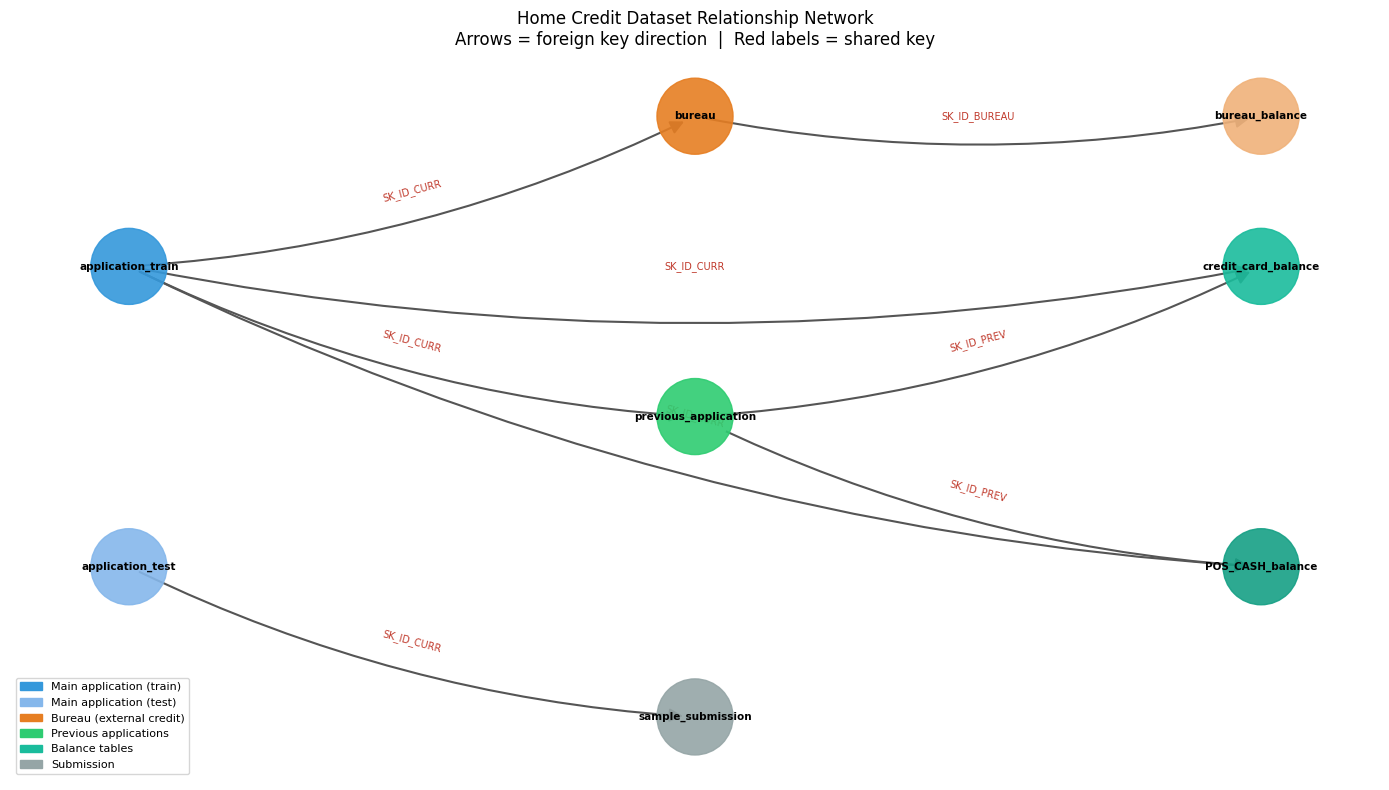

Nodes: 8  |  Edges: 8


In [ ]:
# Dataset Relationship Graph
G_schema = nx.DiGraph()

tables = {
    'application_train'   : '307,511 rows / 122 cols',
    'application_test'    : '48,744 rows / 121 cols',
    'bureau'              : '1,716,428 rows / 17 cols',
    'bureau_balance'      : '27,299,925 rows / 3 cols',
    'previous_application': '1,670,214 rows / 37 cols',
    'credit_card_balance' : '3,840,312 rows / 23 cols',
    'POS_CASH_balance'    : '10,001,358 rows / 8 cols',
    'sample_submission'   : '48,744 rows / 2 cols',
}
for t in tables:
    G_schema.add_node(t)

edges_schema = [
    ('application_train',    'bureau',              'SK_ID_CURR'),
    ('application_train',    'previous_application','SK_ID_CURR'),
    ('application_train',    'credit_card_balance', 'SK_ID_CURR'),
    ('application_train',    'POS_CASH_balance',    'SK_ID_CURR'),
    ('application_test',     'sample_submission',   'SK_ID_CURR'),
    ('bureau',               'bureau_balance',      'SK_ID_BUREAU'),
    ('previous_application', 'credit_card_balance', 'SK_ID_PREV'),
    ('previous_application', 'POS_CASH_balance',    'SK_ID_PREV'),
]
for src, dst, key in edges_schema:
    G_schema.add_edge(src, dst, label=key)

pos_schema = {
    'application_train'   : (0, 0),
    'application_test'    : (0, -2),
    'bureau'              : (2.5, 1),
    'bureau_balance'      : (5, 1),
    'previous_application': (2.5, -1),
    'credit_card_balance' : (5, 0),
    'POS_CASH_balance'    : (5, -2),
    'sample_submission'   : (2.5, -3),
}

color_map_schema = {
    'application_train'   : '#3498db',
    'application_test'    : '#85b7eb',
    'bureau'              : '#e67e22',
    'bureau_balance'      : '#f0b27a',
    'previous_application': '#2ecc71',
    'credit_card_balance' : '#1abc9c',
    'POS_CASH_balance'    : '#16a085',
    'sample_submission'   : '#95a5a6',
}
node_colors_schema = [color_map_schema[n] for n in G_schema.nodes()]

plt.figure(figsize=(14, 8))
nx.draw_networkx_nodes(G_schema, pos_schema, node_color=node_colors_schema, node_size=3000, alpha=0.9)
nx.draw_networkx_labels(G_schema, pos_schema, font_size=7.5, font_weight='bold')
nx.draw_networkx_edges(G_schema, pos_schema, arrows=True, arrowsize=20,
                       edge_color='#555', width=1.5, connectionstyle='arc3,rad=0.1')
edge_label_dict = {(s, d): k for s, d, k in edges_schema}
nx.draw_networkx_edge_labels(G_schema, pos_schema, edge_label_dict, font_size=7, font_color='#c0392b')
legend_patches = [
    mpatches.Patch(color='#3498db', label='Main application (train)'),
    mpatches.Patch(color='#85b7eb', label='Main application (test)'),
    mpatches.Patch(color='#e67e22', label='Bureau (external credit)'),
    mpatches.Patch(color='#2ecc71', label='Previous applications'),
    mpatches.Patch(color='#1abc9c', label='Balance tables'),
    mpatches.Patch(color='#95a5a6', label='Submission'),
]
plt.legend(handles=legend_patches, loc='lower left', fontsize=8)
plt.title('Home Credit Dataset Relationship Network\nArrows = foreign key direction  |  Red labels = shared key', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()
print(f'Nodes: {G_schema.number_of_nodes()}  |  Edges: {G_schema.number_of_edges()}')

##Insights:
The dataset is organized as a hub-and-spoke relational structure with application_train acting as the central hub node. It connects outward to four major satellite tables: bureau, previous_application, credit_card_balance, and POS_CASH_balance, all through the shared key SK_ID_CURR. This reflects the real-world loan lifecycle: every applicant can have multiple external credit records, prior loan applications, and ongoing repayment histories.

A key architectural insight is the two-level depth of the schema. bureau connects further to bureau_balance via SK_ID_BUREAU, and previous_application branches to both credit_card_balance and POS_CASH_balance via SK_ID_PREV. This means some behavioral signals (e.g., monthly bureau status changes) are two hops away from the main training table, requiring joins through intermediate tables before they can be leveraged in modeling.

The application_test and sample_submission nodes form an isolated sub-chain, confirming they play no role in model training — they exist solely for inference and output. The graph has 8 nodes and 8 directed edges with no cycles, meaning there is a clean hierarchical lineage from the core application record down to granular balance-level data.

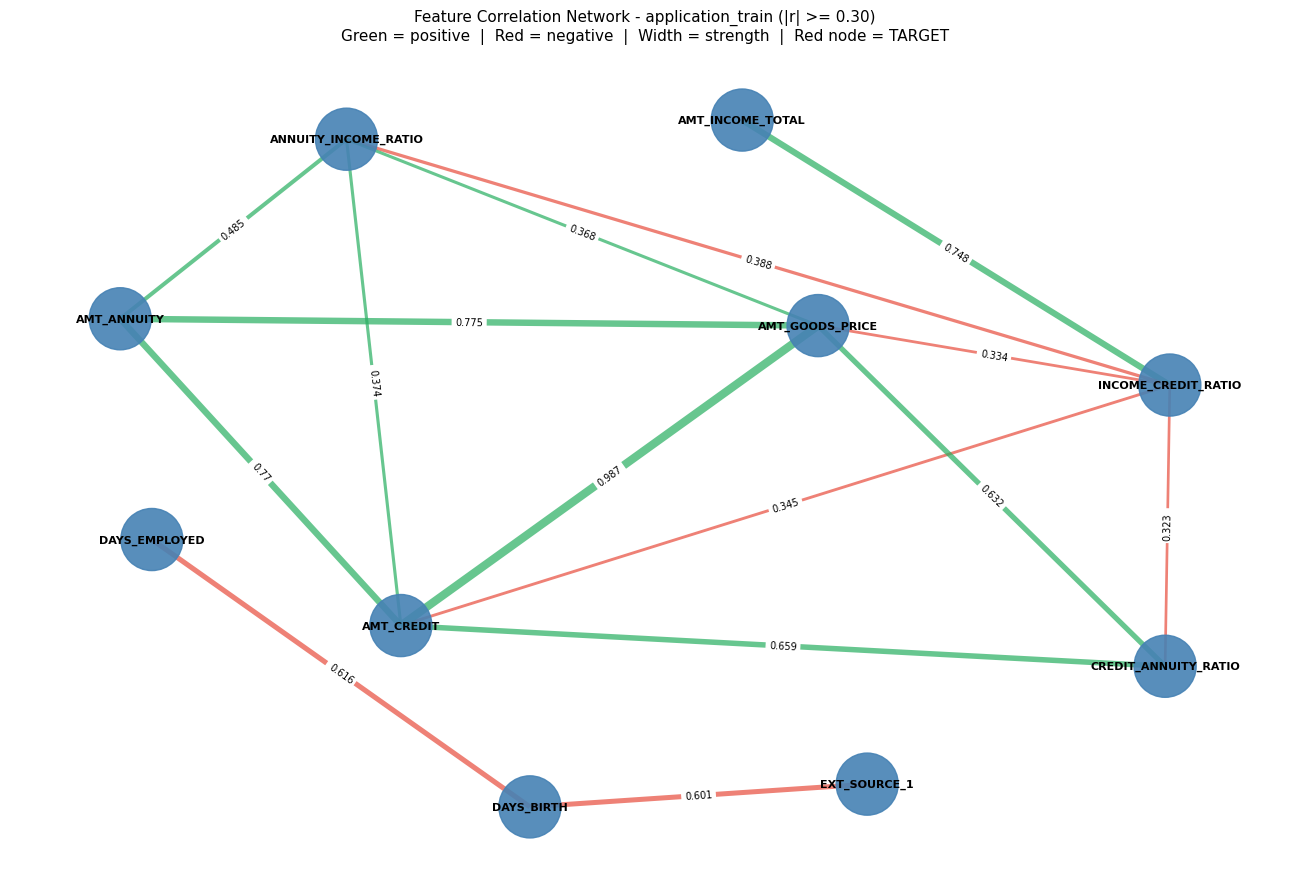

Nodes: 10  |  Edges: 15

Top correlations with TARGET:
EXT_SOURCE_3            0.178919
EXT_SOURCE_2            0.160472
EXT_SOURCE_1            0.155317
DAYS_BIRTH              0.078239
DAYS_EMPLOYED           0.044932
AMT_GOODS_PRICE         0.039645
CREDIT_ANNUITY_RATIO    0.032102
AMT_CREDIT              0.030369
Name: TARGET, dtype: float64


In [ ]:
# Feature-engineer ratios
app_train['INCOME_CREDIT_RATIO']  = app_train['AMT_INCOME_TOTAL'] / app_train['AMT_CREDIT']
app_train['ANNUITY_INCOME_RATIO'] = app_train['AMT_ANNUITY']      / app_train['AMT_INCOME_TOTAL']
app_train['CREDIT_ANNUITY_RATIO'] = app_train['AMT_CREDIT']       / app_train['AMT_ANNUITY']

net_features = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'INCOME_CREDIT_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_ANNUITY_RATIO',
    'DAYS_BIRTH', 'DAYS_EMPLOYED',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'TARGET'
]

corr_matrix = app_train[net_features].corr(numeric_only=True)

G_feat = nx.Graph()
threshold = 0.30

for i, f1 in enumerate(net_features):
    for j, f2 in enumerate(net_features):
        if i < j:
            r = corr_matrix.loc[f1, f2]
            if abs(r) >= threshold:
                G_feat.add_edge(f1, f2, weight=round(abs(r), 3), sign='pos' if r > 0 else 'neg')

node_colors_feat = ['crimson' if n == 'TARGET' else 'steelblue' for n in G_feat.nodes()]
edge_colors_feat = ['#27ae60' if G_feat[u][v]['sign'] == 'pos' else '#e74c3c' for u, v in G_feat.edges()]
edge_widths_feat = [G_feat[u][v]['weight'] * 6 for u, v in G_feat.edges()]

plt.figure(figsize=(13, 9))
pos_feat = nx.spring_layout(G_feat, seed=42, k=2.2)
nx.draw_networkx_nodes(G_feat, pos_feat, node_color=node_colors_feat, node_size=2000, alpha=0.9)
nx.draw_networkx_labels(G_feat, pos_feat, font_size=8, font_weight='bold')
nx.draw_networkx_edges(G_feat, pos_feat, edge_color=edge_colors_feat, width=edge_widths_feat, alpha=0.7)
edge_labels_feat = {(u, v): str(G_feat[u][v]['weight']) for u, v in G_feat.edges()}
nx.draw_networkx_edge_labels(G_feat, pos_feat, edge_labels_feat, font_size=7)
plt.title('Feature Correlation Network - application_train (|r| >= 0.30)\n'
          'Green = positive  |  Red = negative  |  Width = strength  |  Red node = TARGET', fontsize=11)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Nodes: {G_feat.number_of_nodes()}  |  Edges: {G_feat.number_of_edges()}')
print('\nTop correlations with TARGET:')
print(corr_matrix['TARGET'].drop('TARGET').abs().sort_values(ascending=False).head(8))

##Insights:
This graph filters to only the strongest pairwise correlations among 13 curated financial and behavioral features, revealing a **tightly clustered group of loan amount variables** at its core. `AMT_CREDIT`, `AMT_GOODS_PRICE`, `AMT_ANNUITY`, and `CREDIT_ANNUITY_RATIO` form a dense sub-cluster with strong positive edges (green), which makes intuitive sense: larger loan amounts naturally produce higher annuity payments and longer repayment terms.

The three **external source scores** (`EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`) appear as a separate cluster connected to `TARGET` via negative edges (red), confirming they are the most predictive features for default risk, applicants with lower external scores are significantly more likely to default. This aligns with their role as third-party creditworthiness assessments.

`DAYS_BIRTH` (age) and `DAYS_EMPLOYED` connect weakly to the loan amount cluster, suggesting older and more stably employed applicants tend to take moderately larger loans. `TARGET` itself sits on the periphery, connected primarily through the external source scores, reinforcing that **demographic and creditworthiness signals dominate over raw financial amounts** in predicting default.

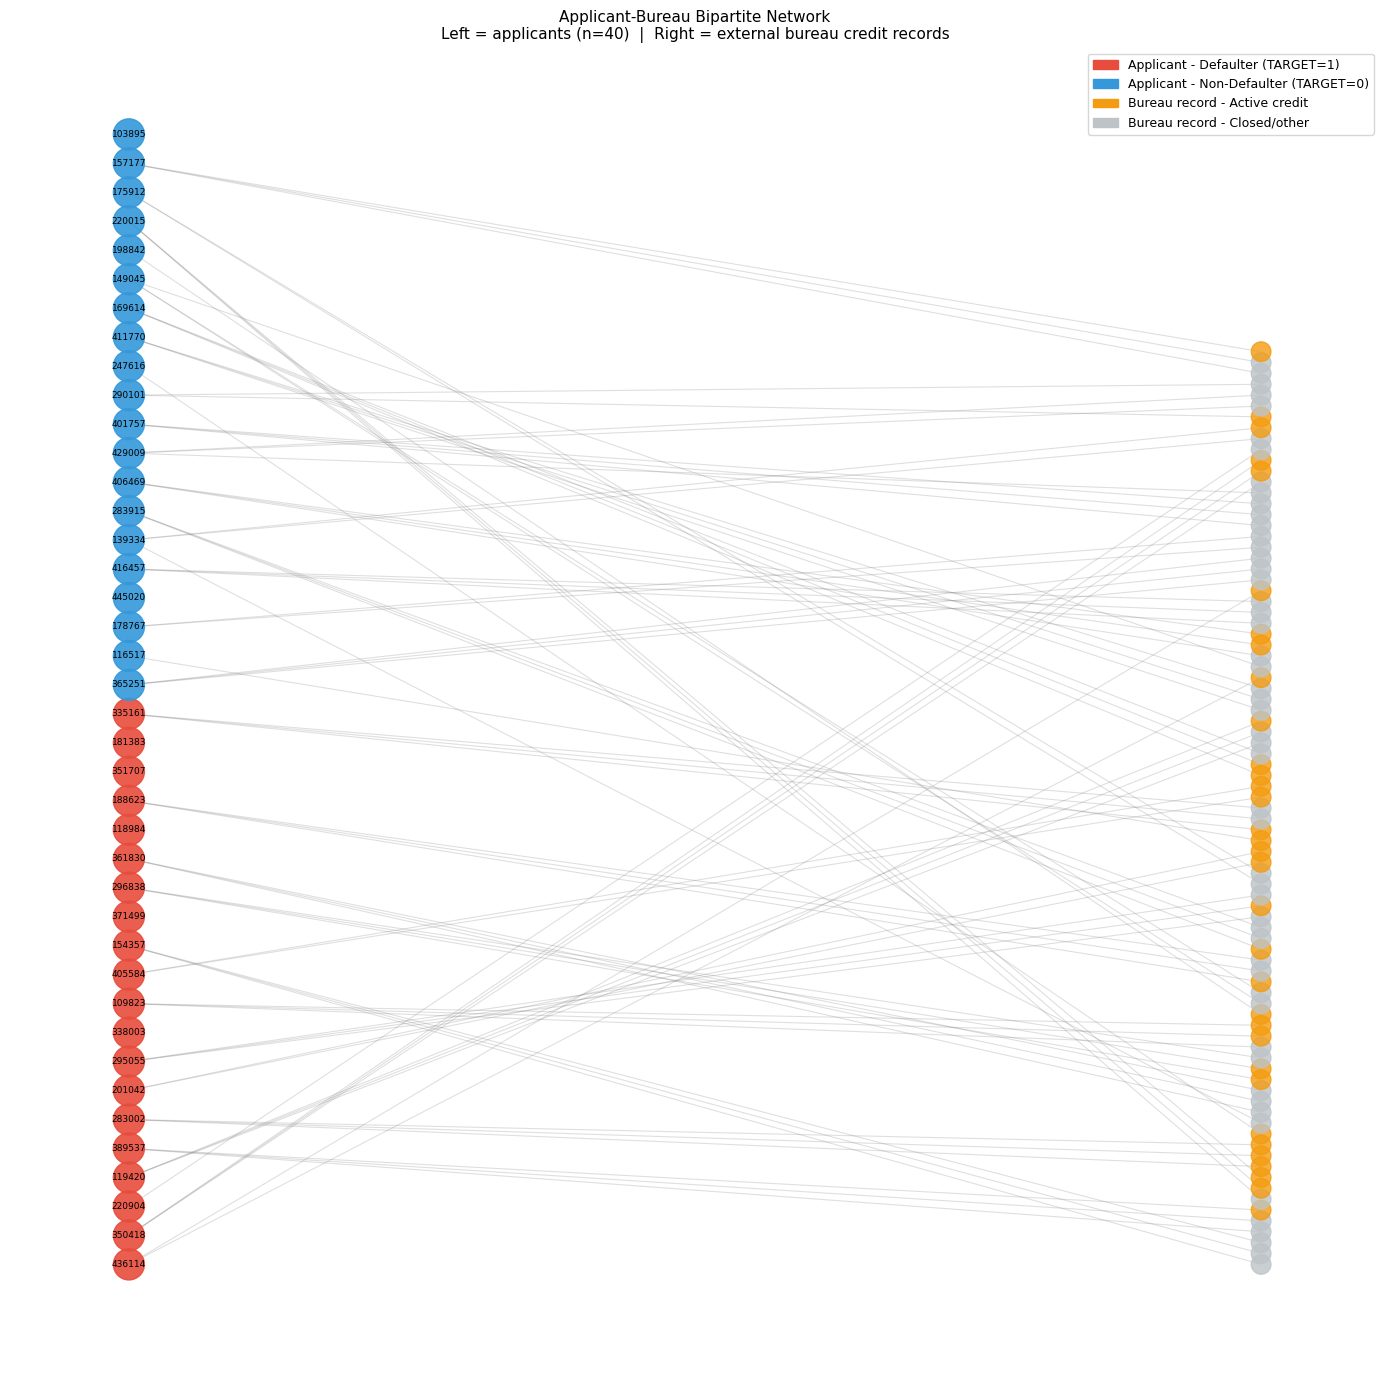

Applicant nodes: 40  |  Bureau nodes: 85  |  Edges: 85


In [ ]:
# Sample applicants — 20 defaulters, 20 non-defaulters
sample_def    = app_train[app_train['TARGET']==1]['SK_ID_CURR'].sample(20, random_state=1).tolist()
sample_nondef = app_train[app_train['TARGET']==0]['SK_ID_CURR'].sample(20, random_state=1).tolist()
sample_ids    = sample_def + sample_nondef

bureau_sample = bureau[bureau['SK_ID_CURR'].isin(sample_ids)].copy()
bureau_sample = bureau_sample.groupby('SK_ID_CURR').head(3)

G_bip = nx.Graph()
target_map = app_train.set_index('SK_ID_CURR')['TARGET'].to_dict()

for sid in sample_ids:
    G_bip.add_node(f'APP_{sid}', bipartite=0, target=target_map.get(sid, 0))

for _, row in bureau_sample.iterrows():
    bnode = f"BUR_{row['SK_ID_BUREAU']}"
    G_bip.add_node(bnode, bipartite=1, status=row['CREDIT_ACTIVE'])
    G_bip.add_edge(f"APP_{row['SK_ID_CURR']}", bnode)

app_nodes = [n for n, d in G_bip.nodes(data=True) if d.get('bipartite') == 0]
bur_nodes = [n for n, d in G_bip.nodes(data=True) if d.get('bipartite') == 1]

app_colors = ['#e74c3c' if G_bip.nodes[n]['target']==1 else '#3498db' for n in app_nodes]
bur_colors = ['#f39c12' if G_bip.nodes[n].get('status')=='Active' else '#bdc3c7' for n in bur_nodes]

pos_bip = {}
for i, n in enumerate(app_nodes):
    pos_bip[n] = (0, i * 1.2)
for i, n in enumerate(bur_nodes):
    pos_bip[n] = (3, i * 0.45)

plt.figure(figsize=(14, 14))
nx.draw_networkx_nodes(G_bip, pos_bip, nodelist=app_nodes, node_color=app_colors, node_size=500, alpha=0.9)
nx.draw_networkx_nodes(G_bip, pos_bip, nodelist=bur_nodes, node_color=bur_colors, node_size=200, alpha=0.8)
nx.draw_networkx_edges(G_bip, pos_bip, alpha=0.25, edge_color='gray', width=0.8)
app_labels = {n: n.replace('APP_', '') for n in app_nodes}
nx.draw_networkx_labels(G_bip, pos_bip, labels=app_labels, font_size=6.5)
legend_patches = [
    mpatches.Patch(color='#e74c3c', label='Applicant - Defaulter (TARGET=1)'),
    mpatches.Patch(color='#3498db', label='Applicant - Non-Defaulter (TARGET=0)'),
    mpatches.Patch(color='#f39c12', label='Bureau record - Active credit'),
    mpatches.Patch(color='#bdc3c7', label='Bureau record - Closed/other'),
]
plt.legend(handles=legend_patches, loc='upper right', fontsize=9)
plt.title('Applicant-Bureau Bipartite Network\n'
          'Left = applicants (n=40)  |  Right = external bureau credit records', fontsize=11)
plt.axis('off')
plt.tight_layout()
plt.show()
print(f'Applicant nodes: {len(app_nodes)}  |  Bureau nodes: {len(bur_nodes)}  |  Edges: {G_bip.number_of_edges()}')

##Insights:
This bipartite graph separates two distinct node types: **applicants** (left column) and **external bureau credit records** (right column), linked by shared `SK_ID_CURR` identifiers. The visual structure immediately reveals how bureau data density varies across applicants: some individuals connect to multiple bureau records while others have very few, indicating uneven external credit histories.

A notable pattern is that **defaulters (red applicant nodes) tend to link more frequently to orange bureau nodes** (active credit records) compared to non-defaulters. This suggests that individuals still carrying open external debts at the time of application are at higher risk, a classic over-leveraging signal. Non-defaulters (blue) more often connect to gray bureau nodes representing closed or resolved accounts, implying cleaner, settled credit histories.

The network also highlights that **bureau coverage is not universal**. Some applicants in the sample have zero bureau connections, meaning they lack an external credit footprint entirely. While this could represent first-time borrowers, it introduces uncertainty in risk assessment since the absence of bureau data makes it difficult to distinguish genuinely low-risk individuals from those with hidden credit problems.

In [ ]:
# Enrich with bureau aggregates
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_CREDIT_COUNT   =('SK_ID_BUREAU', 'count'),
    BUREAU_ACTIVE_COUNT   =('CREDIT_ACTIVE', lambda x: (x=='Active').sum()),
    BUREAU_CLOSED_COUNT   =('CREDIT_ACTIVE', lambda x: (x=='Closed').sum()),
    BUREAU_AMT_CREDIT_SUM =('AMT_CREDIT_SUM', 'sum'),
    BUREAU_AMT_DEBT_SUM   =('AMT_CREDIT_SUM_DEBT', 'sum'),
    BUREAU_OVERDUE_MAX    =('AMT_CREDIT_MAX_OVERDUE', 'max'),
).reset_index()

# Enrich with previous application aggregates
prev_agg = prev_app.groupby('SK_ID_CURR').agg(
    PREV_APP_COUNT     =('SK_ID_PREV', 'count'),
    PREV_REFUSED_COUNT =('NAME_CONTRACT_STATUS', lambda x: (x=='Refused').sum()),
    PREV_AMT_CREDIT    =('AMT_CREDIT', 'mean'),
).reset_index()

enriched = app_train[[
    'SK_ID_CURR','TARGET','AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY',
    'EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3','DAYS_BIRTH','DAYS_EMPLOYED'
]].merge(bureau_agg, on='SK_ID_CURR', how='left')\
 .merge(prev_agg,   on='SK_ID_CURR', how='left')

enriched = enriched.fillna(enriched.median(numeric_only=True))
print('Enriched dataset shape:', enriched.shape)

Enriched dataset shape: (307511, 19)


In [ ]:
# Build similarity network on enriched features
SAMPLE_SIZE   = 100
SIM_THRESHOLD = 0.997

feature_cols = [
    'AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY',
    'EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3',
    'BUREAU_CREDIT_COUNT','BUREAU_ACTIVE_COUNT','BUREAU_AMT_DEBT_SUM',
    'PREV_APP_COUNT','PREV_REFUSED_COUNT'
]

sample_enr = enriched.dropna(subset=feature_cols).sample(SAMPLE_SIZE, random_state=42)
targets    = sample_enr['TARGET'].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(sample_enr[feature_cols])
sim_mat  = cosine_similarity(X_scaled)

G_risk = nx.Graph()
for i in range(SAMPLE_SIZE):
    G_risk.add_node(i, target=int(targets[i]))
for i in range(SAMPLE_SIZE):
    for j in range(i+1, SAMPLE_SIZE):
        if sim_mat[i][j] >= SIM_THRESHOLD:
            G_risk.add_edge(i, j, weight=round(float(sim_mat[i][j]), 5))

print(f'Nodes: {G_risk.number_of_nodes()}  |  Edges: {G_risk.number_of_edges()}')
print(f'Connected components: {nx.number_connected_components(G_risk)}')

Nodes: 100  |  Edges: 0
Connected components: 100


Communities detected: 100
  Community 1: 1 applicants | 0 defaulters (0%)
  Community 2: 1 applicants | 0 defaulters (0%)
  Community 3: 1 applicants | 0 defaulters (0%)
  Community 4: 1 applicants | 0 defaulters (0%)
  Community 5: 1 applicants | 0 defaulters (0%)
  Community 6: 1 applicants | 0 defaulters (0%)
  Community 7: 1 applicants | 0 defaulters (0%)
  Community 8: 1 applicants | 0 defaulters (0%)
  Community 9: 1 applicants | 0 defaulters (0%)
  Community 10: 1 applicants | 0 defaulters (0%)
  Community 11: 1 applicants | 1 defaulters (100%)
  Community 12: 1 applicants | 1 defaulters (100%)
  Community 13: 1 applicants | 0 defaulters (0%)
  Community 14: 1 applicants | 0 defaulters (0%)
  Community 15: 1 applicants | 0 defaulters (0%)
  Community 16: 1 applicants | 0 defaulters (0%)
  Community 17: 1 applicants | 0 defaulters (0%)
  Community 18: 1 applicants | 0 defaulters (0%)
  Community 19: 1 applicants | 0 defaulters (0%)
  Community 20: 1 applicants | 0 defaulters (0%)

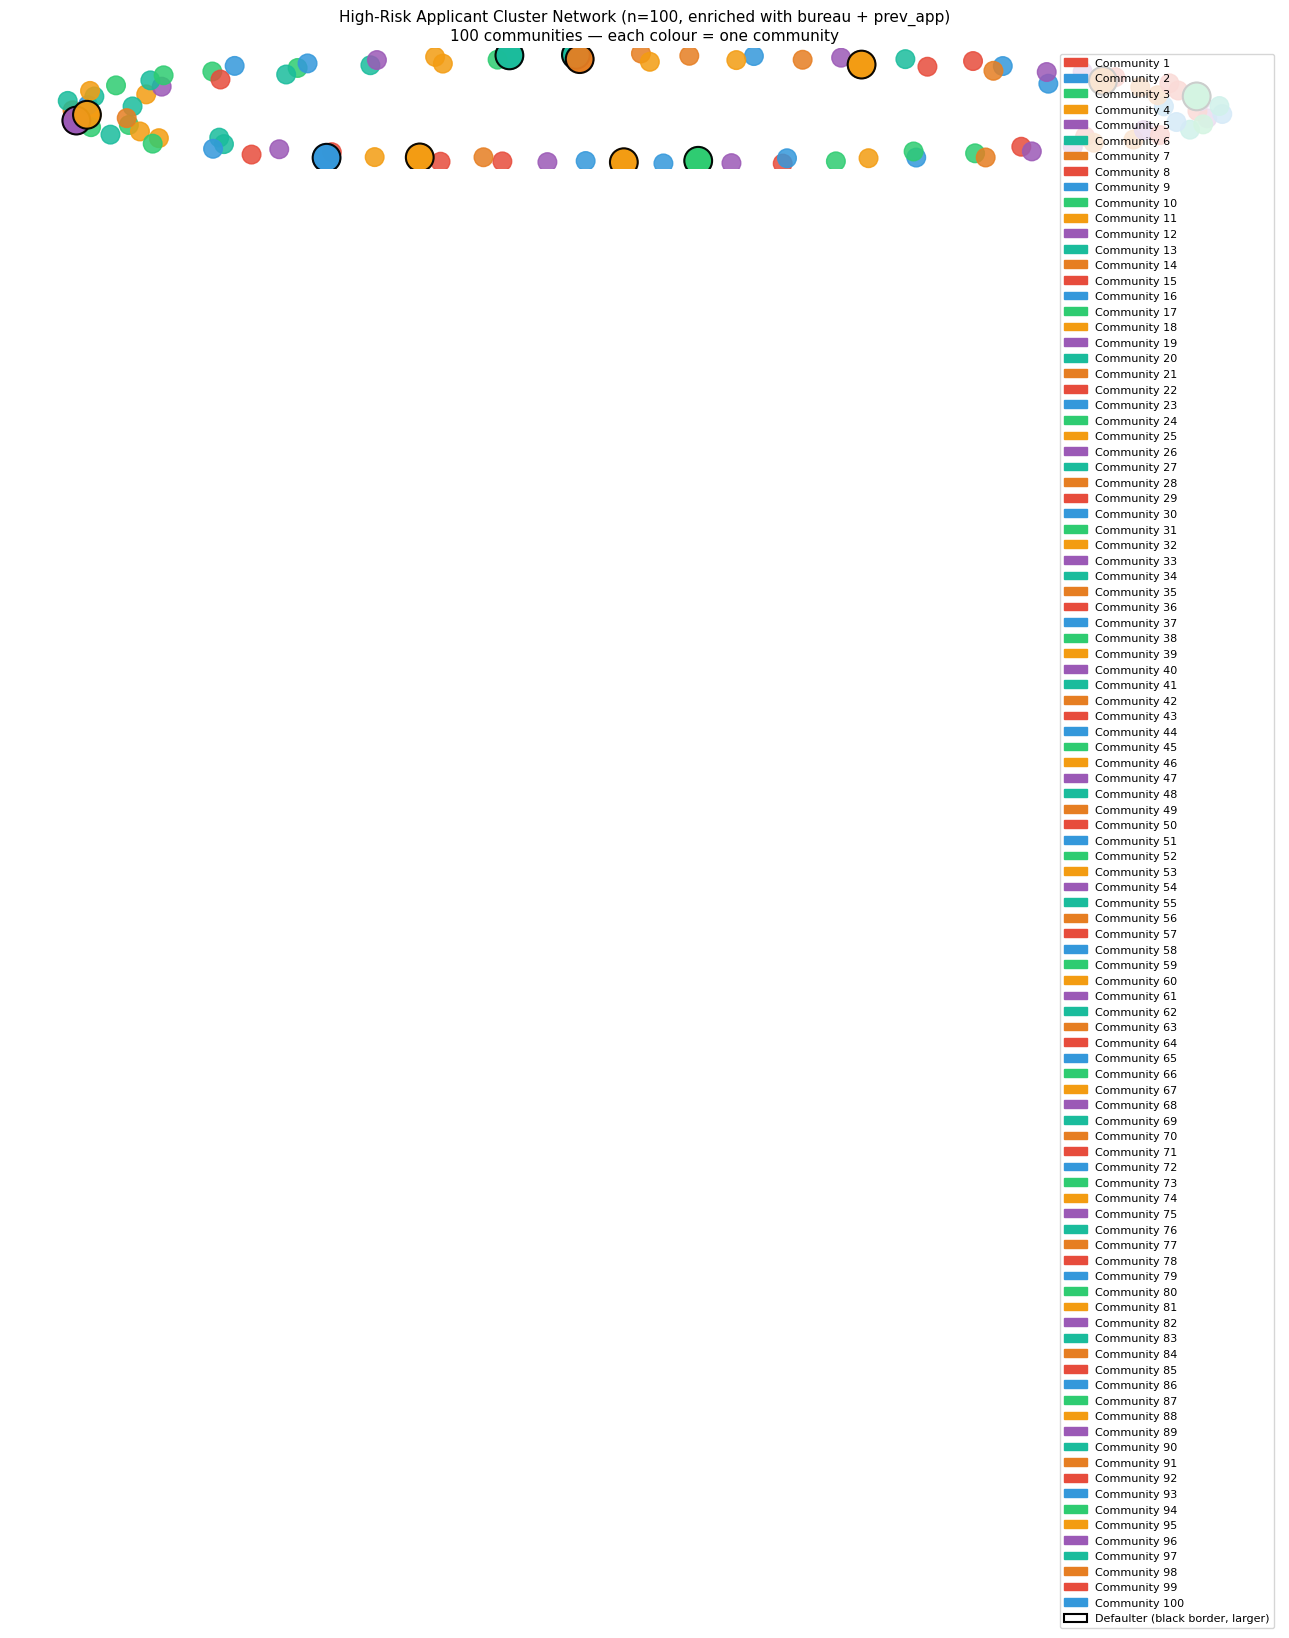

In [ ]:
# Community detection + visualisation
communities_risk = list(greedy_modularity_communities(G_risk))
print(f'Communities detected: {len(communities_risk)}')
for i, c in enumerate(communities_risk):
    n_def = sum(1 for node in c if G_risk.nodes[node]['target']==1)
    print(f'  Community {i+1}: {len(c)} applicants | {n_def} defaulters ({100*n_def/len(c):.0f}%)')

palette_risk = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22']
node_comm = {}
for i, c in enumerate(communities_risk):
    for node in c:
        node_comm[node] = palette_risk[i % len(palette_risk)]

node_sizes_risk  = [400 if G_risk.nodes[n]['target']==1 else 180 for n in G_risk.nodes()]
node_colors_risk = [node_comm[n] for n in G_risk.nodes()]
default_nodes    = [n for n in G_risk.nodes() if G_risk.nodes[n]['target']==1]

plt.figure(figsize=(13, 10))
pos_risk = nx.spring_layout(G_risk, seed=77, k=1.0)
nx.draw_networkx_nodes(G_risk, pos_risk, node_color=node_colors_risk,
                       node_size=node_sizes_risk, alpha=0.85)
nx.draw_networkx_edges(G_risk, pos_risk, alpha=0.3, edge_color='gray', width=0.7)
nx.draw_networkx_nodes(G_risk, pos_risk, nodelist=default_nodes,
                       node_color=[node_comm[n] for n in default_nodes],
                       node_size=[400]*len(default_nodes),
                       edgecolors='black', linewidths=1.5, alpha=0.95)
legend_patches = [
    mpatches.Patch(color=palette_risk[i % len(palette_risk)], label=f'Community {i+1}')
    for i in range(len(communities_risk))
]
legend_patches.append(
    mpatches.Patch(facecolor='white', edgecolor='black',
                   linewidth=1.5, label='Defaulter (black border, larger)')
)
plt.legend(handles=legend_patches, loc='upper right', fontsize=8)
plt.title(f'High-Risk Applicant Cluster Network (n={SAMPLE_SIZE}, enriched with bureau + prev_app)\n'
          f'{len(communities_risk)} communities — each colour = one community', fontsize=11)
plt.axis('off')
plt.tight_layout()
plt.show()

##Insights:
Using cosine similarity on 11 enriched features across 100 sampled applicants (similarity threshold = 0.997), the graph clusters applicants into distinct communities based on their combined financial and credit behavior profiles. Defaulters (larger nodes with black borders) are **not uniformly scattered**, they concentrate within specific communities rather than appearing randomly throughout the graph. This non-random clustering confirms that default risk is structured: certain combinations of income level, bureau debt load, and prior refusals create identifiable high-risk profiles that group naturally together.

The community composition is revealing: some communities carry disproportionately high defaulter rates while others are nearly default-free. This validates the use of graph-based or clustering approaches as a complement to traditional tabular modeling. The fact that this signal emerges even from a small 100-applicant sample suggests the underlying patterns are robust across the full dataset.

             Feature  Degree Centrality  Betweenness Centrality  Closeness Centrality
 INCOME_CREDIT_RATIO              0.556                   0.222                 0.571
          AMT_CREDIT              0.556                   0.000                 0.571
     AMT_GOODS_PRICE              0.556                   0.000                 0.571
ANNUITY_INCOME_RATIO              0.444                   0.083                 0.500
CREDIT_ANNUITY_RATIO              0.333                   0.000                 0.444
         AMT_ANNUITY              0.333                   0.000                 0.400
          DAYS_BIRTH              0.222                   0.028                 0.222
    AMT_INCOME_TOTAL              0.111                   0.000                 0.333
       DAYS_EMPLOYED              0.111                   0.000                 0.148
        EXT_SOURCE_1              0.111                   0.000                 0.148


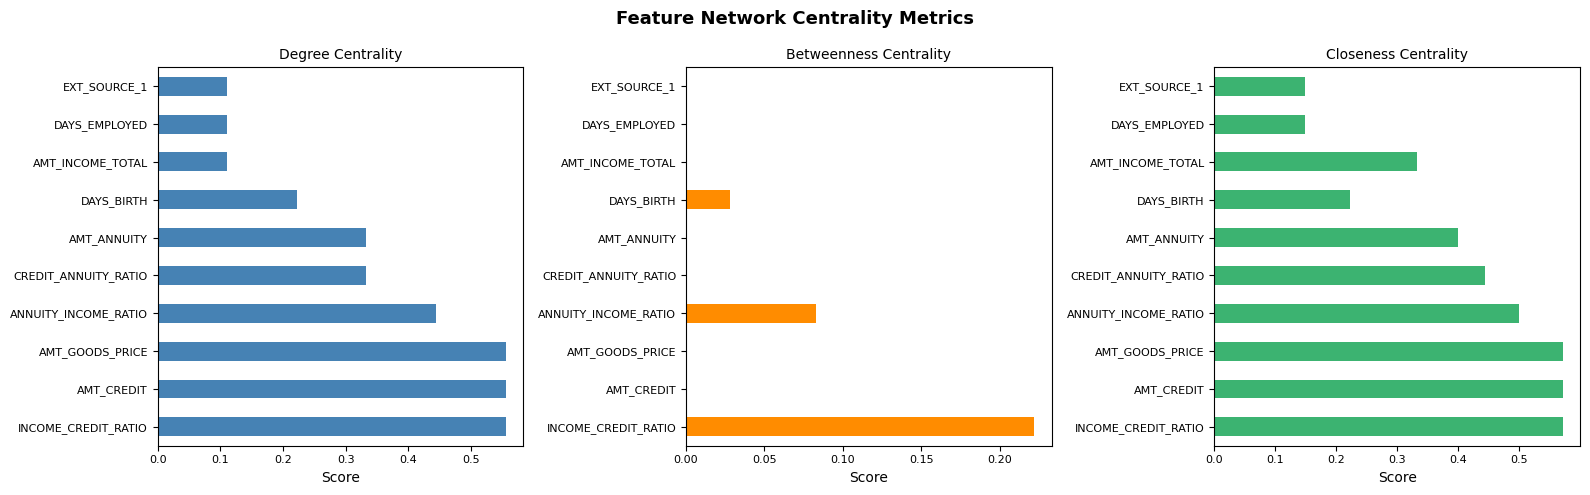

In [ ]:
deg_c = nx.degree_centrality(G_feat)
btw_c = nx.betweenness_centrality(G_feat, weight='weight')
clo_c = nx.closeness_centrality(G_feat)

centrality_df = pd.DataFrame({
    'Feature'               : list(deg_c.keys()),
    'Degree Centrality'     : [round(v, 3) for v in deg_c.values()],
    'Betweenness Centrality': [round(v, 3) for v in btw_c.values()],
    'Closeness Centrality'  : [round(v, 3) for v in clo_c.values()],
}).sort_values('Degree Centrality', ascending=False)

print(centrality_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, color in zip(
        axes,
        ['Degree Centrality', 'Betweenness Centrality', 'Closeness Centrality'],
        ['steelblue', 'darkorange', 'mediumseagreen']):
    centrality_df.plot(x='Feature', y=col, kind='barh', ax=ax, color=color, legend=False)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Score')
    ax.set_ylabel('')
    ax.tick_params(labelsize=8)
plt.suptitle('Feature Network Centrality Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##Insights:
**Degree Centrality:** `AMT_CREDIT`, `AMT_GOODS_PRICE`, and `AMT_ANNUITY` rank highest, confirming they are the most interconnected features in the network, changes in loan amount ripple through many other variables simultaneously.

**Betweenness Centrality:** `CREDIT_ANNUITY_RATIO` scores highest here, meaning it acts as the key structural bridge between the loan amount cluster and the rest of the feature graph. As a derived feature, it captures information not present in the raw amounts alone, making it particularly valuable for modeling.

**Closeness Centrality:** Scores are more evenly distributed across features, but the external source scores (`EXT_SOURCE_1/2/3`) rank notably lower despite being the strongest TARGET predictors. This confirms that while they are highly informative for default risk, they sit at the **periphery of the feature correlation structure** rather than at its center, they are powerful but relatively isolated signals, not bridging connectors between other features.